# Chronumental dating summary

Residual statistics and predicted-vs-reported date plots for the
per-segment chronumental runs (HA × subtype, NA × subtype).
Internal segments (PB2/PB1/PA/NP/MP/NS) are not dated — see
`Snakefile` rule `chronumental_subtype` and `CLAUDE.md` for why.

## Imports

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')

## Load metadata and locate per-tree chronumental outputs

In [2]:
meta = pd.read_csv("../results/combined_metadata_augmented.csv",
                   usecols=["isolate_id", "collection_date"])
meta_full = meta[meta["collection_date"].str.fullmatch(r"\d{4}-\d{2}-\d{2}", na=False)].copy()
meta_full["true_date"] = pd.to_datetime(meta_full["collection_date"])
meta_full = meta_full[["isolate_id", "true_date"]]
print(f"Loaded {len(meta_full)} samples with fully-resolved YYYY-MM-DD dates")

# Find all per-tree chronumental outputs (HA + NA only)
trees = []
for segment in ["HA", "NA"]:
    for subtype_dir in sorted(Path(f"../results/{segment}").glob("*")):
        tsv = subtype_dir / "final_tree_dates.tsv"
        if tsv.exists():
            trees.append((segment, subtype_dir.name, tsv))
print(f"Found chronumental outputs for {len(trees)} per-segment trees")

Loaded 463589 samples with fully-resolved YYYY-MM-DD dates
Found chronumental outputs for 10 per-segment trees


## Per-tree residual statistics

For every leaf with a parseable `collection_date`, the residual is
`predicted_date - reported_date` in days.

In [3]:
rows = []
all_pairs = []  # leaf-level (true, predicted) for scatter plots
for segment, subtype, tsv in trees:
    dates = pd.read_csv(tsv, sep="\t")
    leaves = dates[dates["strain"].str.match(r"(EPI_ISL_|NC_)")].rename(
        columns={"strain": "isolate_id"})
    m = leaves.merge(meta_full, on="isolate_id", how="inner").copy()
    m["pred_date"] = pd.to_datetime(m["predicted_date"], errors="coerce")
    m = m.dropna(subset=["pred_date"])
    m["diff_days"] = (m["pred_date"] - m["true_date"]).dt.days

    ref_path = tsv.parent / "chronumental_reference.txt"
    ref = ref_path.read_text().strip() if ref_path.exists() else ""

    rows.append({
        "tree": f"{segment}/{subtype}",
        "reference": ref,
        "n_total_nodes": len(dates),
        "n_tips_with_truth": len(m),
        "median_|res|_days": int(m["diff_days"].abs().median()),
        "p95_|res|_days": int(m["diff_days"].abs().quantile(0.95)),
        "max_|res|_days": int(m["diff_days"].abs().max()),
    })

    sub = m[["isolate_id", "true_date", "pred_date", "diff_days"]].copy()
    sub["tree"] = f"{segment}/{subtype}"
    all_pairs.append(sub)

summary = pd.DataFrame(rows)
all_pairs_df = pd.concat(all_pairs, ignore_index=True)
summary

,tree,reference,n_total_nodes,n_tips_with_truth,median_|res|_days,p95_|res|_days,max_|res|_days
0,HA/H1,EPI_ISL_129471,119291,78160,1,12,43205
1,HA/H3,EPI_ISL_111135,112602,73633,0,2,7032
2,HA/H5,EPI_ISL_17767822,29748,17483,3,26,41566
3,HA/H7,EPI_ISL_5799,4699,2443,0,1,39
4,HA/H9,EPI_ISL_397995,12665,6352,1,2,967
5,NA/N1,EPI_ISL_8796,107066,70553,1,3,5885
6,NA/N2,EPI_ISL_8907,103706,66836,1,12,20203
7,NA/N6,EPI_ISL_22518,5780,2903,0,1,139
8,NA/N8,EPI_ISL_15353,6398,2555,1,3,104
9,NA/N9,EPI_ISL_131363,2889,1743,1,1,16


## Predicted vs reported leaf dates

One panel per tree. Dashed line is `y = x`.

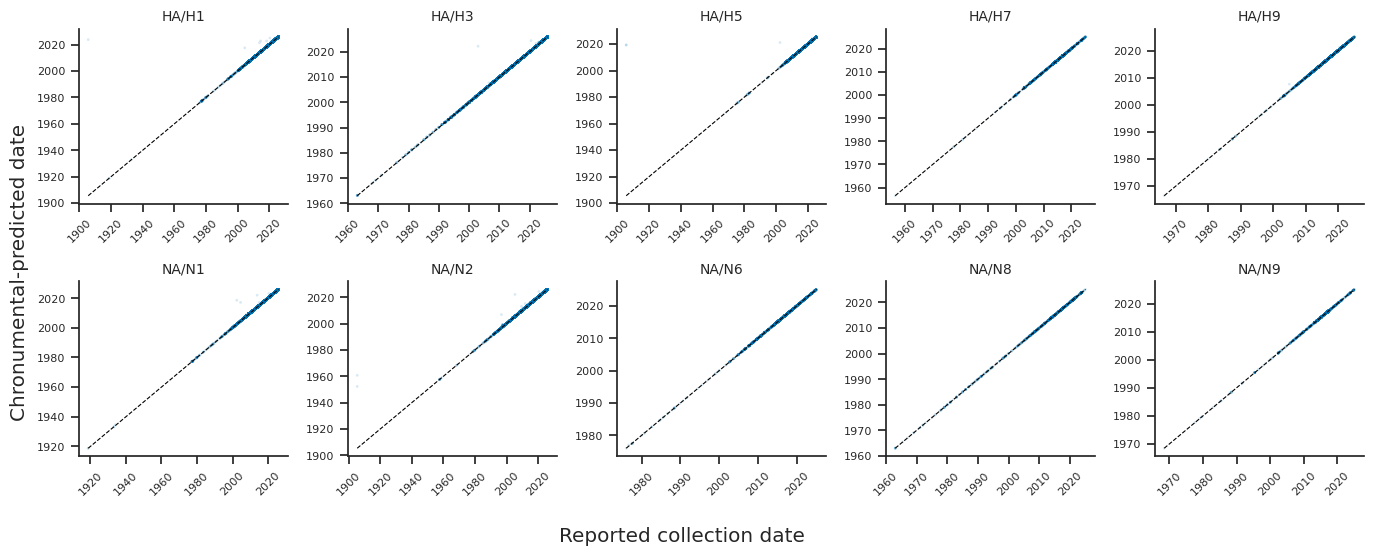

In [4]:
trees_in_order = summary["tree"].tolist()
n = len(trees_in_order)
ncols = 5
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 2.8, nrows * 2.8))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i, tree_name in enumerate(trees_in_order):
    ax = axes[i]
    s = all_pairs_df[all_pairs_df["tree"] == tree_name]
    ax.scatter(s["true_date"], s["pred_date"],
               alpha=0.15, s=4, color="#0173B2", edgecolor="none")
    lo = min(s["true_date"].min(), s["pred_date"].min())
    hi = max(s["true_date"].max(), s["pred_date"].max())
    ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=0.8)
    ax.set_title(tree_name, fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    sns.despine(ax=ax)

for j in range(n, len(axes)):
    axes[j].axis("off")

fig.supxlabel("Reported collection date")
fig.supylabel("Chronumental-predicted date")
plt.tight_layout()
os.makedirs("../results/figures/", exist_ok=True)
plt.savefig("../results/figures/chronumental_pred_vs_reported.png",
            dpi=200, bbox_inches="tight")
plt.show()

## Median |residual| per tree

/tmp/ipykernel_3365762/2512580335.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha="right")


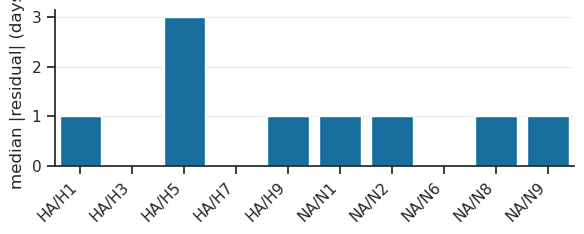

In [5]:
fig, ax = plt.subplots(figsize=(6, 2.5))
order = summary["tree"].tolist()
sns.barplot(data=summary, x="tree", y="median_|res|_days",
            order=order, ax=ax, color="#0173B2")
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_ylabel("median |residual| (days)")
ax.set_xlabel("")
ax.yaxis.grid(True, alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("../results/figures/chronumental_median_residual.png",
            dpi=200, bbox_inches="tight")
plt.show()

## Residual distribution per tree

Stacked histograms of `predicted - reported` (days). Vertical line at zero.

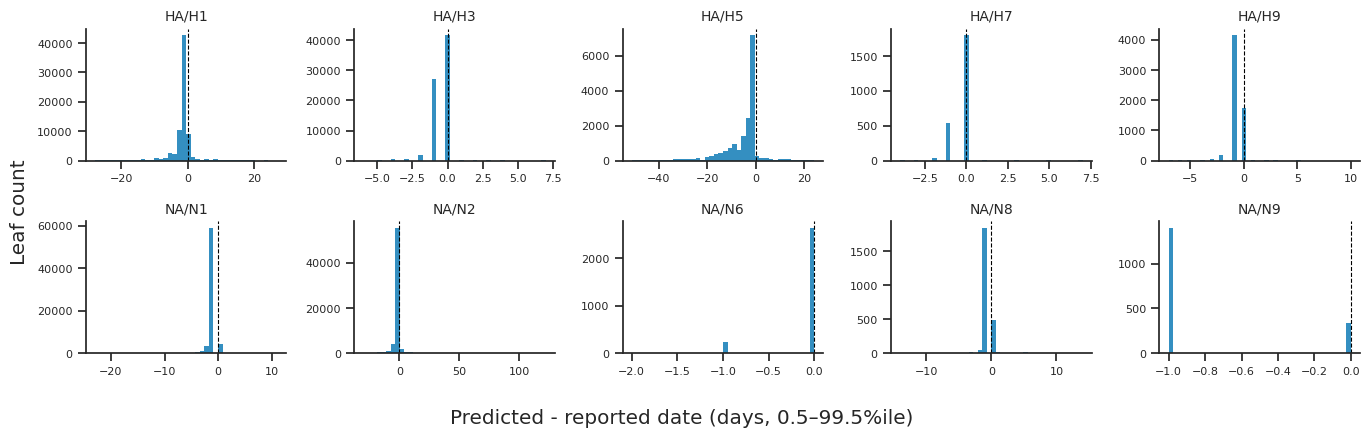

In [6]:
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 2.8, nrows * 2.2),
                         sharex=False)
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i, tree_name in enumerate(trees_in_order):
    ax = axes[i]
    s = all_pairs_df[all_pairs_df["tree"] == tree_name]["diff_days"]
    # Clip extreme outliers (metadata errors) for visualisation,
    # using a robust 99th-percentile window.
    lo, hi = np.percentile(s, [0.5, 99.5])
    sub = s[(s >= lo) & (s <= hi)]
    ax.hist(sub, bins=40, color="#0173B2", alpha=0.8, edgecolor="none")
    ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(tree_name, fontsize=10)
    ax.tick_params(labelsize=8)
    sns.despine(ax=ax)

for j in range(n, len(axes)):
    axes[j].axis("off")

fig.supxlabel("Predicted - reported date (days, 0.5–99.5%ile)")
fig.supylabel("Leaf count")
plt.tight_layout()
plt.savefig("../results/figures/chronumental_residual_hist.png",
            dpi=200, bbox_inches="tight")
plt.show()